[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Statically-determinate truss vibration

Last updated: 07/12/26

## Problem description

A simple truss is analyzed for free vibration. The truss is statically determinate.

The frequencies are compared to the reference values.

## References

MECHANICAL VIBRATIONS THEORY AND APPLICATION TO STRUCTURAL
DYNAMICS, ThirdEdition, by Michel Géradin and Daniel J. Rixen

Example from Section 5.3.2: 2D Truss Analysis

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


In [1]:
import scipy
from math import pi, sqrt
from numpy.linalg import norm
import context 
from pystran import model
from pystran import section
from pystran import plots

The material properties and the geometry of the truss are assumed here at
these values. The frequencies are compared in normalized form, which removes
the direct dependency on the adopted numbers.


In [2]:
E = 30000000.0
rho = 1.0
L = 5.0
A = 0.0155

Table 5.4 in the reference book gives the normalized frequencies.


In [3]:
reference_values = [0.03428, 0.05810, 0.08901, 0.1215, 0.1947, 0.2342]

The normalized frequency is given by the formula:


In [4]:
def normalized_analyt(om2):
    return sqrt(om2) / 2 / pi * sqrt(rho / E) * L

The geometry is given in Figure 5.15 of the reference book.


In [5]:
m = model.create(2)
freedoms = m["freedoms"]

In [6]:
model.add_joint(m, 1, [0.0, 0.0])
model.add_joint(m, 2, [1 * L, 0.0])
model.add_joint(m, 3, [2 * L, 0.0])
model.add_joint(m, 4, [3 * L, 0.0])
model.add_joint(m, 5, [1 * L, L])
model.add_joint(m, 6, [2 * L, L])

In [7]:
s1 = section.truss_section("s1", E, A, rho)

In [8]:
model.add_truss_member(m, 1, [1, 2], s1)
model.add_truss_member(m, 2, [2, 3], s1)
model.add_truss_member(m, 3, [3, 4], s1)
model.add_truss_member(m, 4, [1, 5], s1)
model.add_truss_member(m, 5, [5, 6], s1)
model.add_truss_member(m, 6, [6, 4], s1)
model.add_truss_member(m, 7, [2, 5], s1)
model.add_truss_member(m, 8, [2, 6], s1)
model.add_truss_member(m, 9, [3, 6], s1)

In [9]:
model.add_support(m["joints"][1], freedoms.U1)
model.add_support(m["joints"][1], freedoms.U2)
model.add_support(m["joints"][4], freedoms.U2)

The free vibration problem is solved.

In [10]:
model.number_dofs(m)
model.solve_free_vibration(m)

The frequencies are printed and compared to the reference values.
In particular, the normalized frequencies are compared.



Mode 0:  37.55046858343898
  Normalized frequency:  0.03427873114673098


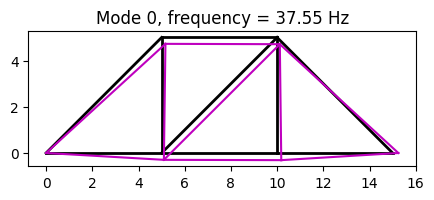

Mode 1:  63.641905966945956
  Normalized frequency:  0.058096845834531556


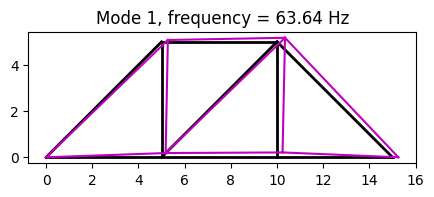

Mode 2:  97.50585627519257
  Normalized frequency:  0.08901026161796603


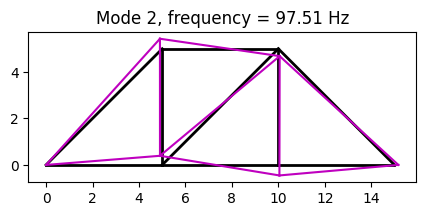

Mode 3:  133.0485231651255
  Normalized frequency:  0.12145612896714646


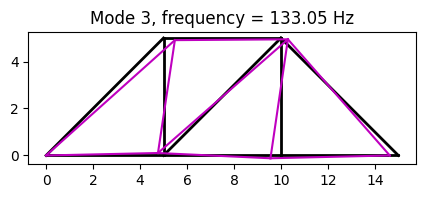

Mode 4:  213.25075060975269
  Normalized frequency:  0.19467041085645015


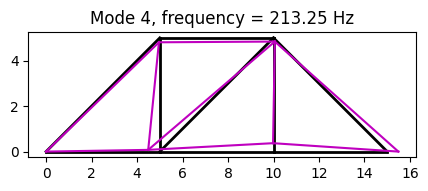

Mode 5:  256.52465950409953
  Normalized frequency:  0.23417390427787885


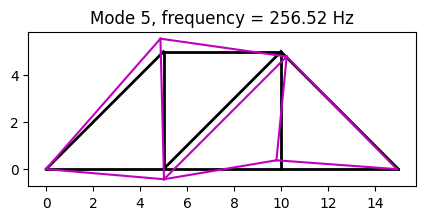

In [11]:
for mode in range(0, 6):
    print(f"Mode {mode}: ", m["frequencies"][mode])
    print(f"  Normalized frequency: ", normalized_analyt(m["eigvals"][mode]))
    if (
        abs(
            (reference_values[mode] - normalized_analyt(m["eigvals"][mode]))
            / reference_values[mode]
        )
        > 1.0e-3
    ):
        raise ValueError("Error in the normalized frequency")
    ax = plots.setup(m)
    plots.plot_members(m)
    model.set_solution(m, m["eigvecs"][:, mode])
    plots.plot_deformations(m, 0.25)
    ax.set_title(f"Mode {mode}, frequency = {m['frequencies'][mode]:.2f} Hz")
    plots.show(m)


## Conclusions

A truss structure was analyzed for it free-vibration response. Good agreement with the reference values was obtained.